In [12]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [13]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test  = pd.read_csv('y_test.csv')

print('Shapes:')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

Shapes:
X_train: (9592, 9)
X_test : (2399, 9)
y_train: (9592, 1)
y_test : (2399, 1)


In [14]:
y_train = y_train.values.ravel()
y_test  = y_test.values.ravel()

print('y_train type:', type(y_train), '| shape:', y_train.shape)
print('y_test  type:', type(y_test),  '| shape:', y_test.shape)
print('Class distribution in y_train:', dict(zip(*np.unique(y_train, return_counts=True))))

y_train type: <class 'numpy.ndarray'> | shape: (9592,)
y_test  type: <class 'numpy.ndarray'> | shape: (2399,)
Class distribution in y_train: {np.int64(0): np.int64(7999), np.int64(1): np.int64(1593)}


In [15]:
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print('X_train shape after encoding:', X_train.shape)
print('X_test  shape after encoding:', X_test.shape)

X_train shape after encoding: (9592, 20)
X_test  shape after encoding: (2399, 20)


In [16]:
rf = RandomForestClassifier(random_state=0)

param_distributions = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 5, 10, None],
    'max_features'      : ['sqrt', 'log2'],
    'max_samples'       : [0.7, 0.8, 1.0],
    'min_samples_leaf'  : [1, 2, 3],
    'min_samples_split' : [2, 3, 4]
}

print('Hyperparameter grid defined.')
print('Total possible combinations:', 3*4*2*3*3*3)
print('RandomizedSearchCV will sample: 20 (n_iter=20)')

Hyperparameter grid defined.
Total possible combinations: 648
RandomizedSearchCV will sample: 20 (n_iter=20)


In [17]:
rf_cv = RandomizedSearchCV(
    estimator          = rf,
    param_distributions= param_distributions,
    n_iter             = 20,        # only 20 random combos (vs 648 in GridSearch)
    scoring            = 'roc_auc', # optimize for AUC
    cv                 = 4,         # 4-fold cross validation
    refit              = True,      # refit best model on full train data
    random_state       = 0,
    n_jobs             = -1,        # use ALL CPU cores — biggest speedup!
    verbose            = 1          # prints progress
)

print('RandomizedSearchCV configured.')
print('Total fits = n_iter x cv =', 20, 'x', 4, '=', 80)

RandomizedSearchCV configured.
Total fits = n_iter x cv = 20 x 4 = 80


In [18]:
start_time = time.time()

rf_cv.fit(X_train, y_train)

end_time = time.time()
elapsed = end_time - start_time

print(f'\nTraining Time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)')
print('\nBest Parameters Found:')
for param, value in rf_cv.best_params_.items():
    print(f'  {param}: {value}')
print(f'\nBest CV ROC-AUC Score: {rf_cv.best_score_:.4f}')

Fitting 4 folds for each of 20 candidates, totalling 80 fits

Training Time: 59.26 seconds (0.99 minutes)

Best Parameters Found:
  n_estimators: 200
  min_samples_split: 4
  min_samples_leaf: 1
  max_samples: 0.7
  max_features: sqrt
  max_depth: None

Best CV ROC-AUC Score: 0.9803


In [19]:
best_rf = rf_cv.best_estimator_

y_pred      = best_rf.predict(X_test)
y_pred_proba= best_rf.predict_proba(X_test)[:, 1]

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba)

print('=' * 40)
print('       TEST SET METRICS')
print('=' * 40)
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {auc:.4f}')
print('=' * 40)

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

       TEST SET METRICS
Accuracy  : 0.9854
Precision : 0.9840
Recall    : 0.9271
F1 Score  : 0.9547
ROC-AUC   : 0.9828

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.98      0.93      0.95       398

    accuracy                           0.99      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



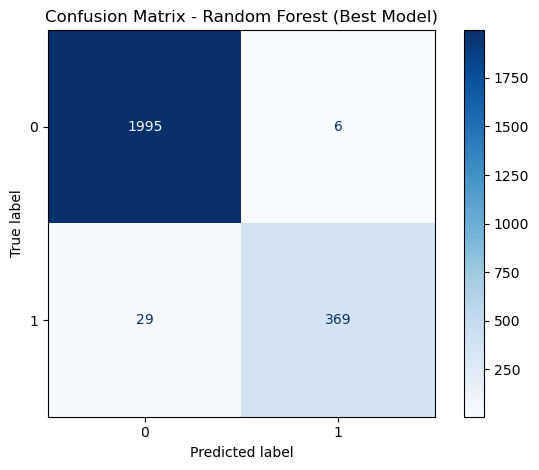

Confusion matrix saved as confusion_matrix.png


In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest (Best Model)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved as confusion_matrix.png')

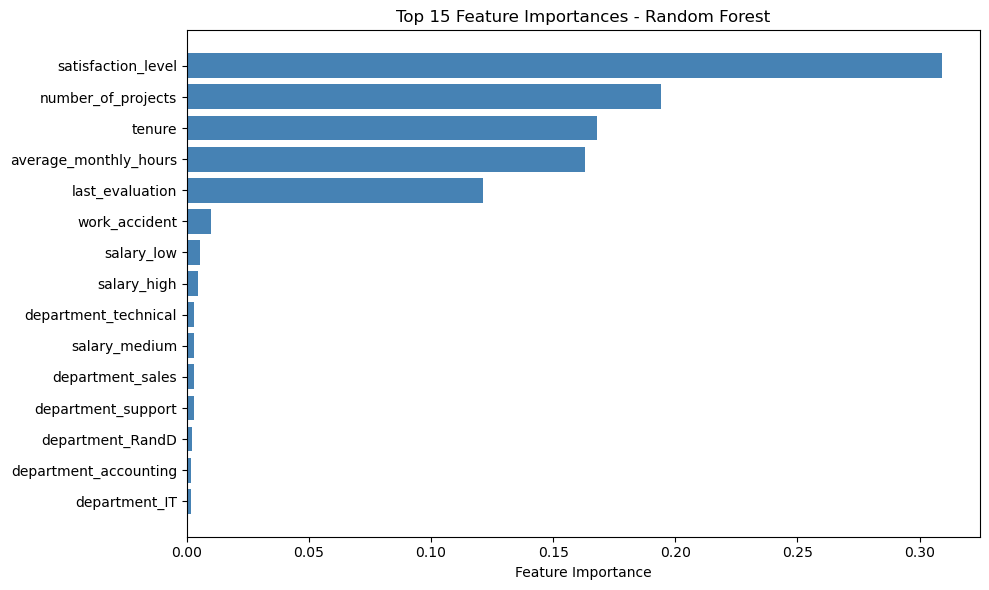


Top 15 Features:
              Feature  Importance
   satisfaction_level    0.309292
   number_of_projects    0.194187
               tenure    0.168089
average_monthly_hours    0.163152
      last_evaluation    0.121102
        work_accident    0.009811
           salary_low    0.005535
          salary_high    0.004535
 department_technical    0.003086
        salary_medium    0.002988
     department_sales    0.002878
   department_support    0.002787
     department_RandD    0.002105
department_accounting    0.001737
        department_IT    0.001592


In [21]:
importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

print('\nTop 15 Features:')
print(feat_df.to_string(index=False))

In [22]:
cv_results = pd.DataFrame(rf_cv.cv_results_)

cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_n_estimators', 'param_max_depth', 'param_max_features',
        'param_max_samples', 'param_min_samples_leaf', 'param_min_samples_split']

top5 = cv_results[cols].sort_values('rank_test_score').head(5)
print('Top 5 Hyperparameter Combinations by ROC-AUC:')
print(top5.to_string(index=False))

Top 5 Hyperparameter Combinations by ROC-AUC:
 rank_test_score  mean_test_score  std_test_score  param_n_estimators param_max_depth param_max_features  param_max_samples  param_min_samples_leaf  param_min_samples_split
               1         0.980252        0.003674                 200            None               sqrt                0.7                       1                        4
               2         0.980220        0.003194                 300            None               sqrt                0.8                       3                        2
               3         0.980136        0.003422                 100            None               sqrt                0.8                       3                        2
               4         0.979845        0.002577                 300            None               log2                0.8                       1                        4
               5         0.979755        0.003529                 300              10    